<a href="https://colab.research.google.com/github/Balamurugan-T326/DEEP-LEARNING/blob/main/EXPERIMENT-7/PART-A%2CB%2CC%2CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A — Dataset preparation and preprocessing

In [19]:
print("24BAD016-BALAMURUGAN T")


import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Roll Number: 24BCS310")
print("TensorFlow Version:", tf.__version__)

24BAD016-BALAMURUGAN T
Roll Number: 24BCS310
TensorFlow Version: 2.21.0


Load the MNIST dataset

In [20]:
# Load dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixels to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = x_train[..., np.newaxis]

BATCH_SIZE = 128
BUFFER_SIZE = 60000

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training data shape:", x_train.shape)
print("Training batches:", 60000 // BATCH_SIZE)
print("Pixel range:", x_train.min(), "to", x_train.max())

Training data shape: (60000, 28, 28, 1)
Training batches: 468
Pixel range: -1.0 to 1.0


Display real images

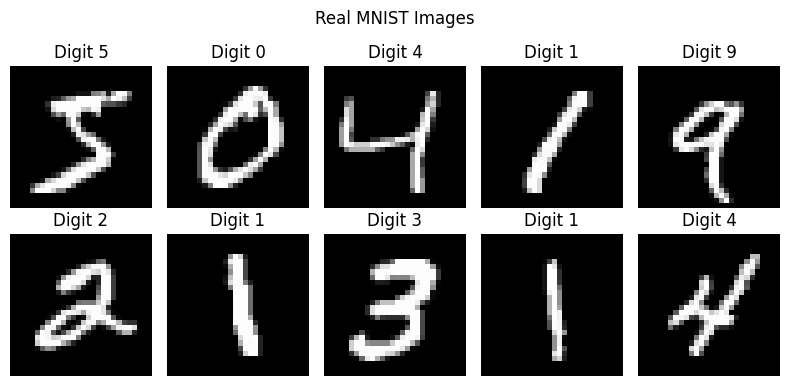

In [21]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i, :, :, 0], cmap="gray")
    plt.title("Digit " + str(y_train[i]))
    plt.axis("off")

plt.suptitle("Real MNIST Images")
plt.tight_layout()
plt.show()

Build the Generator

In [22]:
LATENT_DIM = 100

def build_generator():
    model = keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(LATENT_DIM,)))
    model.add(layers.Dense(7 * 7 * 128, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Reshape((7, 7, 128)))

    model.add(layers.Conv2DTranspose(
        64, kernel_size=4, strides=2,
        padding="same", use_bias=False
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Conv2DTranspose(
        1, kernel_size=4, strides=2,
        padding="same", activation="tanh"
    ))

    return model

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,641 (2.99 MB)

 Trainable params: 771,969 (2.94 MB)

 Non-trainable params: 12,672 (49.50 KB)

Test the Generator before training

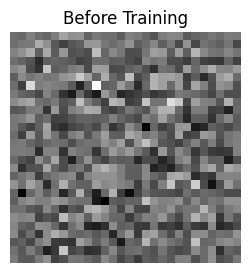

Generated shape: (1, 28, 28, 1)


In [23]:
noise = tf.random.normal([1, LATENT_DIM])
sample = generator(noise, training=False)

plt.figure(figsize=(3, 3))
plt.imshow(sample[0, :, :, 0], cmap="gray")
plt.title("Before Training")
plt.axis("off")
plt.show()

print("Generated shape:", sample.shape)

Build the Discriminator

In [24]:
def build_discriminator():
    model = keras.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(
        64, kernel_size=4, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(
        128, kernel_size=4, strides=2, padding="same"
    ))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,561 (541.25 KB)

 Trainable params: 138,561 (541.25 KB)

 Non-trainable params: 0 (0.00 B)


Set up losses and optimizers

In [25]:
cross_entropy = keras.losses.BinaryCrossentropy()

generator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002, beta_1=0.5
)

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output), fake_output
    )

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output), real_output
    )
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output), fake_output
    )
    return real_loss + fake_loss

print("Loss functions and optimizers are ready.")

Loss functions and optimizers are ready.


Define the GAN training step

In [26]:
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]

    # Train Discriminator
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(
            tf.stop_gradient(fake_images), training=True
        )

        d_loss = discriminator_loss(real_output, fake_output)

    d_gradients = disc_tape.gradient(
        d_loss, discriminator.trainable_variables
    )

    discriminator_optimizer.apply_gradients(
        zip(d_gradients, discriminator.trainable_variables)
    )

    # Train Generator
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape:
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=False)

        g_loss = generator_loss(fake_output)

    g_gradients = gen_tape.gradient(
        g_loss, generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(g_gradients, generator.trainable_variables)
    )

    return g_loss, d_loss

print("GAN training step defined successfully.")

GAN training step defined successfully.


Train the GAN

Epoch 1/5 | G Loss: 0.8568 | D Loss: 1.1922 | Time: 14.9s


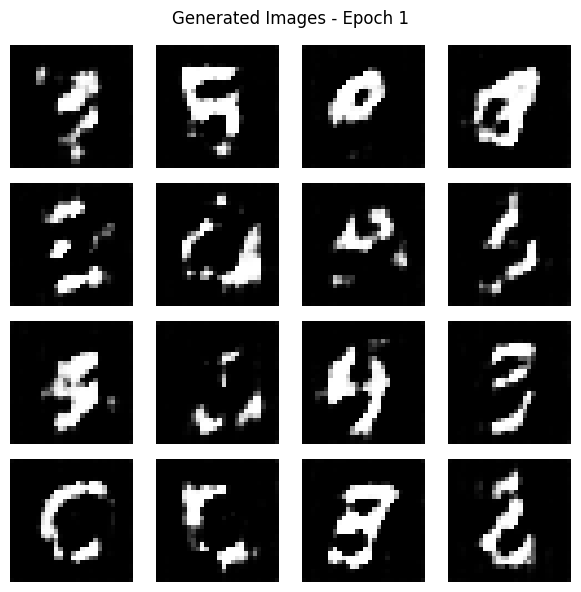

Epoch 2/5 | G Loss: 0.8856 | D Loss: 1.2444 | Time: 8.1s


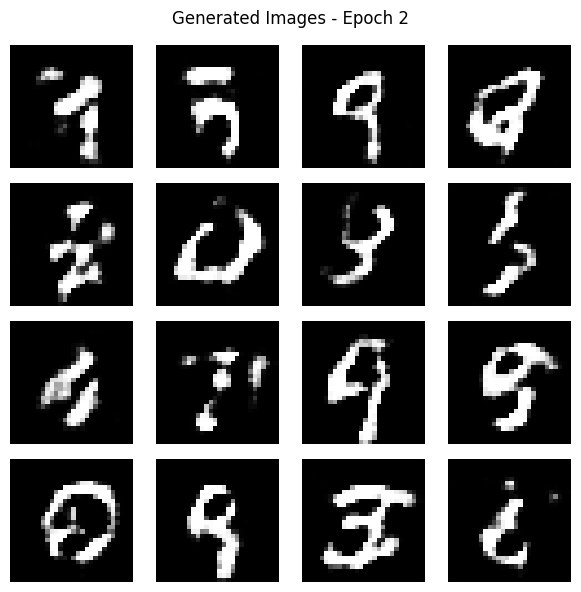

Epoch 3/5 | G Loss: 0.9301 | D Loss: 1.2041 | Time: 7.7s


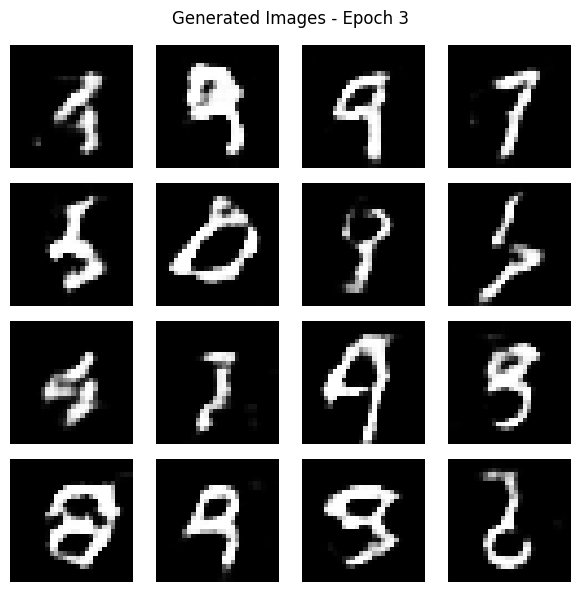

Epoch 4/5 | G Loss: 0.8646 | D Loss: 1.2683 | Time: 7.8s


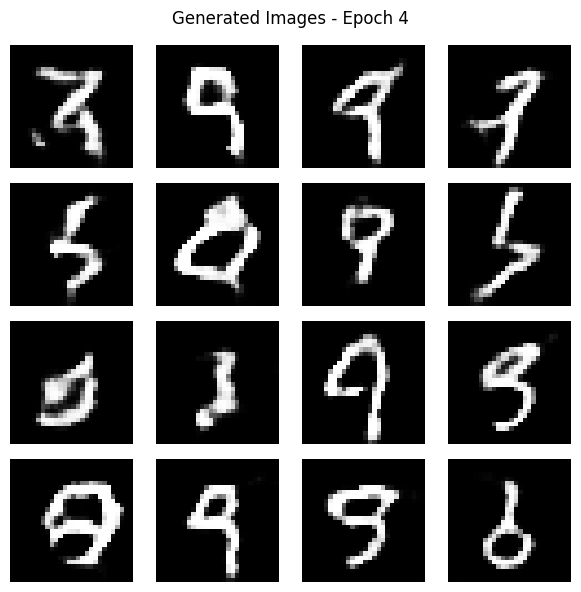

Epoch 5/5 | G Loss: 0.8331 | D Loss: 1.3024 | Time: 9.1s


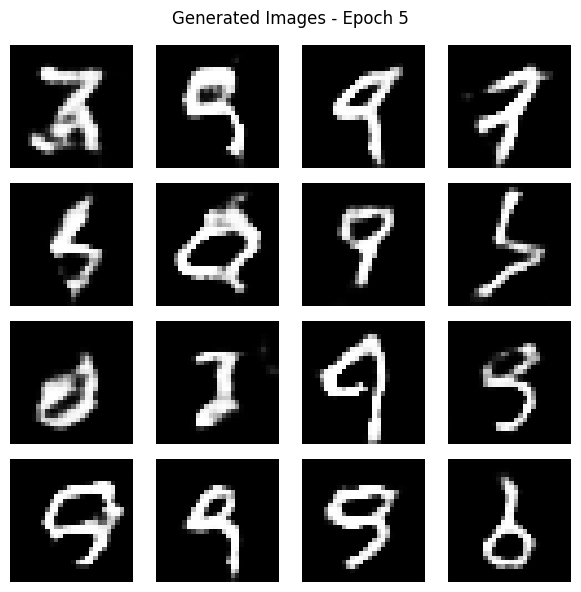

GAN training completed!


In [27]:
EPOCHS = 5

generator_losses = []
discriminator_losses = []

fixed_noise = tf.random.normal([16, LATENT_DIM])

def show_generated_images(epoch):
    images = generator(fixed_noise, training=False)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i, :, :, 0], cmap="gray")
        ax.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch}")
    plt.tight_layout()
    plt.show()

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    g_metric = keras.metrics.Mean()
    d_metric = keras.metrics.Mean()

    for real_batch in train_dataset:
        g_loss, d_loss = train_step(real_batch)
        g_metric.update_state(g_loss)
        d_metric.update_state(d_loss)

    g_value = float(g_metric.result().numpy())
    d_value = float(d_metric.result().numpy())

    generator_losses.append(g_value)
    discriminator_losses.append(d_value)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"G Loss: {g_value:.4f} | "
        f"D Loss: {d_value:.4f} | "
        f"Time: {time.time() - start:.1f}s"
    )

    show_generated_images(epoch)

print("GAN training completed!")

Plot training losses

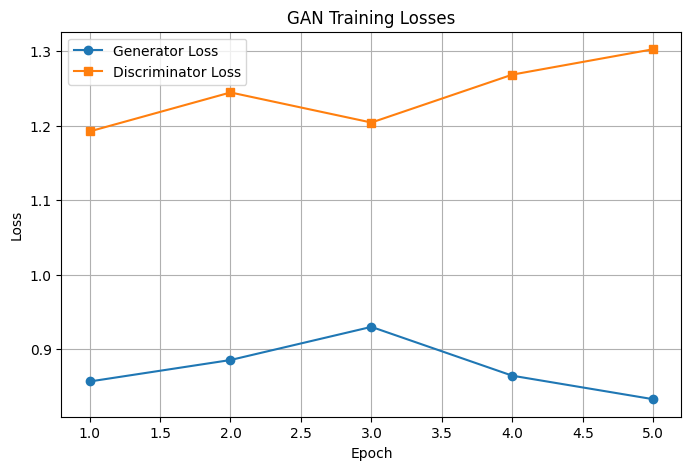

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    marker="o",
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    marker="s",
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

Compare real and generated images

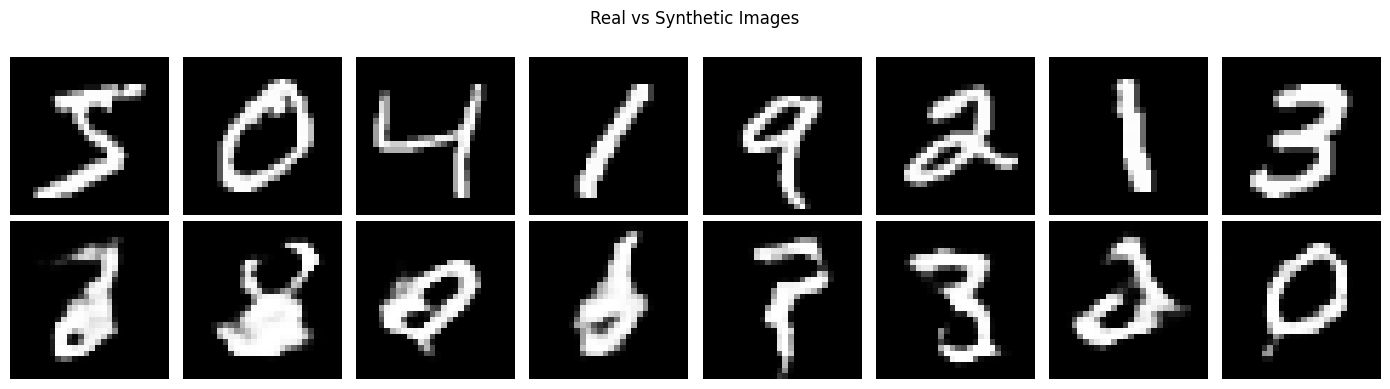

In [29]:
noise = tf.random.normal([8, LATENT_DIM])
fake_images = generator(noise, training=False).numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i in range(8):
    # Convert real and generated images to [0, 1]
    real_image = (x_train[i, :, :, 0] + 1) / 2
    fake_image = (fake_images[i, :, :, 0] + 1) / 2

    axes[0, i].imshow(real_image, cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(fake_image, cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Real")
axes[1, 0].set_ylabel("Generated")

plt.suptitle("Real vs Synthetic Images")
plt.tight_layout()
plt.show()

Save images and the trained model

In [30]:
from PIL import Image

os.makedirs("GAN_Results", exist_ok=True)

noise = tf.random.normal([25, LATENT_DIM])
images = generator(noise, training=False).numpy()

for i in range(25):
    pixels = ((images[i, :, :, 0] + 1) * 127.5)
    pixels = np.clip(pixels, 0, 255).astype(np.uint8)

    Image.fromarray(pixels).save(
        f"GAN_Results/generated_{i + 1:02d}.png"
    )

generator.save("GAN_Results/trained_generator.keras")

print("25 synthetic images saved.")
print("Trained Generator saved.")

25 synthetic images saved.
Trained Generator saved.


Download your results

In [31]:
import shutil
from google.colab import files

shutil.make_archive(
    "GAN_Results_24BCS310",
    "zip",
    "GAN_Results"
)

files.download("GAN_Results_24BCS310.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>